# Realistic Driver-Error Telemetry -- Model Predictive Control (MPC)
### Same strategy, same competition constraints -- imperfect human execution

The existing project generates **perfect** telemetry: the driver follows the optimal strategy exactly, so efficiency is unrealistically high. This notebook regenerates the **same strategy** with a realistic human driver, preserving *every* competition constraint and the telemetry schema, changing **only the execution**.

**Driver errors modelled** (stochastic, bounded, no extreme outliers): (1) speed tracking +/-3%, (2) throttle modulation +/-5%, (3) glide timing 0.3-2.0 s, (4) acceleration timing 0.2-1.5 s, (5) brake timing 0.2-1.0 s, (6) corner entry +/-2 km/h, (7) stop-and-go reaction 0.2-1.2 s, (8) steering line deviation +/-0.3 m; plus **driver fatigue** (error grows 100->108% over the 4 laps) and a **two-motor servo switch** cost (0.5 s default, configurable) that reduces motor power during each accel<->cruise switch.

**Unchanged:** racing-line track, lap distance, corner radius, slope, weather; 4 laps / 35-min cap / start + both stop-and-gos; fuel cell (SZFC-1000), mass, aero, rolling resistance, efficiency maps; and the telemetry columns. Engine: `margin/driver_sim.py`.

In [1]:
import os, sys
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'digital_twin')):
    root = os.path.dirname(root)
os.chdir(root); sys.path.insert(0, os.path.join(root, 'margin')); sys.path.insert(0, root)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
import driver_sim as ds
from digital_twin import config

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 120, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
    'grid.color': '#ececea', 'grid.linewidth': 0.8, 'axes.edgecolor': '#9a9a95',
    'font.size': 11.5, 'axes.titlesize': 13.5, 'axes.titleweight': 'bold', 'axes.titlepad': 10,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

MODEL = 'mpc'; MODEL_DIR = 'MPC'
FIGDIR = os.path.join('margin', MODEL_DIR, 'figures'); os.makedirs(FIGDIR, exist_ok=True)
SERVO_S = 0.5            # default servo switch time (configurable: 0.5 / 1 / 2 / 3 s)
SEED = 42
print('Realistic-driver telemetry for', MODEL.upper(),
      '| motor: BLDC 650W + BG 42x30 dCore | FC: SZFC-1000 | servo', SERVO_S, 's')


Realistic-driver telemetry for MPC | motor: BLDC 650W + BG 42x30 dCore | FC: SZFC-1000 | servo 0.5 s


## 1 - Generate baseline (perfect) + realistic (driver-error) telemetry
Same simulator; error layer off vs on. The realistic CSV is saved schema-identical to the project.

In [2]:
# Baseline = perfect execution re-simulated by the SAME simulator (error off); realistic =
# the driver-error run (error on). Same strategy, same track/vehicle/FC -- only execution differs.
baseline = ds.generate(MODEL, ds.DriverErrorConfig(enabled=False))
realistic = ds.generate(MODEL, ds.DriverErrorConfig(enabled=True, seed=SEED, motor_switch_time_s=SERVO_S))

# schema check vs the existing project telemetry
proj = pd.read_csv(os.path.join('notebooks', MODEL, MODEL + '_attempt_analysis.csv'))
schema_ok = list(realistic.columns) == list(proj.columns) and len(realistic) == len(proj)
print('Schema identical to existing project CSV:', schema_ok, '(', len(realistic.columns), 'columns,', len(realistic), 'rows )')

# save the generated realistic telemetry (schema-identical) + the baseline re-sim
out_csv = os.path.join('margin', MODEL_DIR, MODEL + '_driver_error_telemetry.csv')
realistic.to_csv(out_csv, index=False)
baseline.to_csv(os.path.join('margin', MODEL_DIR, MODEL + '_baseline_resim.csv'), index=False)
print('saved', out_csv)

sb, sr = ds.summary(baseline, 'baseline'), ds.summary(realistic, 'realistic')
print('baseline :', sb)
print('realistic:', sr)


powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


Schema identical to existing project CSV: True ( 57 columns, 2948 rows )
saved margin/MPC/mpc_driver_error_telemetry.csv
baseline : {'label': 'baseline', 'score_km_per_m3': np.float64(203.9), 'h2_litres': np.float64(65.55), 'time_min': np.float64(33.85), 'avg_speed_kmh': np.float64(25.71), 'max_speed_kmh': np.float64(30.1), 'motor_handoffs': 15, 'rule_violations': 0, 'time_ok': True}
realistic: {'label': 'realistic', 'score_km_per_m3': np.float64(191.9), 'h2_litres': np.float64(70.06), 'time_min': np.float64(33.59), 'avg_speed_kmh': np.float64(25.91), 'max_speed_kmh': np.float64(33.3), 'motor_handoffs': 15, 'rule_violations': 0, 'time_ok': True}


## 2 - Comparison with baseline
Efficiency, hydrogen, average speed, time loss, max speed deviation, motor-switching stats.

In [3]:
# ---- Comparison with baseline: the headline metrics the brief asks for ----
dev = (realistic['v_kmh'].to_numpy() - baseline['v_kmh'].to_numpy())     # speed execution error
switch_pts = int((realistic['active_motor'].to_numpy()[1:] != realistic['active_motor'].to_numpy()[:-1]).sum())
cmp = pd.DataFrame([
    {'metric': 'Efficiency (km/m3 H2)',   'baseline': sb['score_km_per_m3'], 'realistic': sr['score_km_per_m3'],
     'change': f"{(sr['score_km_per_m3']-sb['score_km_per_m3'])/sb['score_km_per_m3']*100:+.1f}%"},
    {'metric': 'Hydrogen consumed (L)',   'baseline': sb['h2_litres'], 'realistic': sr['h2_litres'],
     'change': f"{(sr['h2_litres']-sb['h2_litres'])/sb['h2_litres']*100:+.1f}%"},
    {'metric': 'Average speed (km/h)',    'baseline': sb['avg_speed_kmh'], 'realistic': sr['avg_speed_kmh'],
     'change': f"{sr['avg_speed_kmh']-sb['avg_speed_kmh']:+.2f}"},
    {'metric': 'Attempt time (min)',      'baseline': sb['time_min'], 'realistic': sr['time_min'],
     'change': f"{(sr['time_min']-sb['time_min'])*60:+.1f} s"},
    {'metric': 'Max speed deviation (km/h)', 'baseline': 0.0, 'realistic': round(np.abs(dev).max(), 2), 'change': ''},
    {'metric': 'Motor switches',          'baseline': sb['motor_handoffs'], 'realistic': switch_pts, 'change': ''},
    {'metric': 'Servo overhead (s)',      'baseline': 0.0, 'realistic': round(switch_pts*SERVO_S, 1), 'change': ''},
    {'metric': 'Rule violations',         'baseline': sb['rule_violations'], 'realistic': sr['rule_violations'], 'change': ''},
])
display(cmp)
print(f"Time loss vs perfect execution: {(sr['time_min']-sb['time_min'])*60:+.1f} s  |  legal (<35 min): {sr['time_ok']}")


,metric,baseline,realistic,change
0,Efficiency (km/m3 H2),203.90,191.90,-5.9%
1,Hydrogen consumed (L),65.55,70.06,+6.9%
2,Average speed (km/h),25.71,25.91,+0.20
3,Attempt time (min),33.85,33.59,-15.6 s
4,Max speed deviation (km/h),0.00,6.28,
5,Motor switches,15.00,15.00,
6,Servo overhead (s),0.00,7.50,
7,Rule violations,0.00,0.00,


Time loss vs perfect execution: -15.6 s  |  legal (<35 min): True


## 3 - Speed profile: strategy vs realistic driver

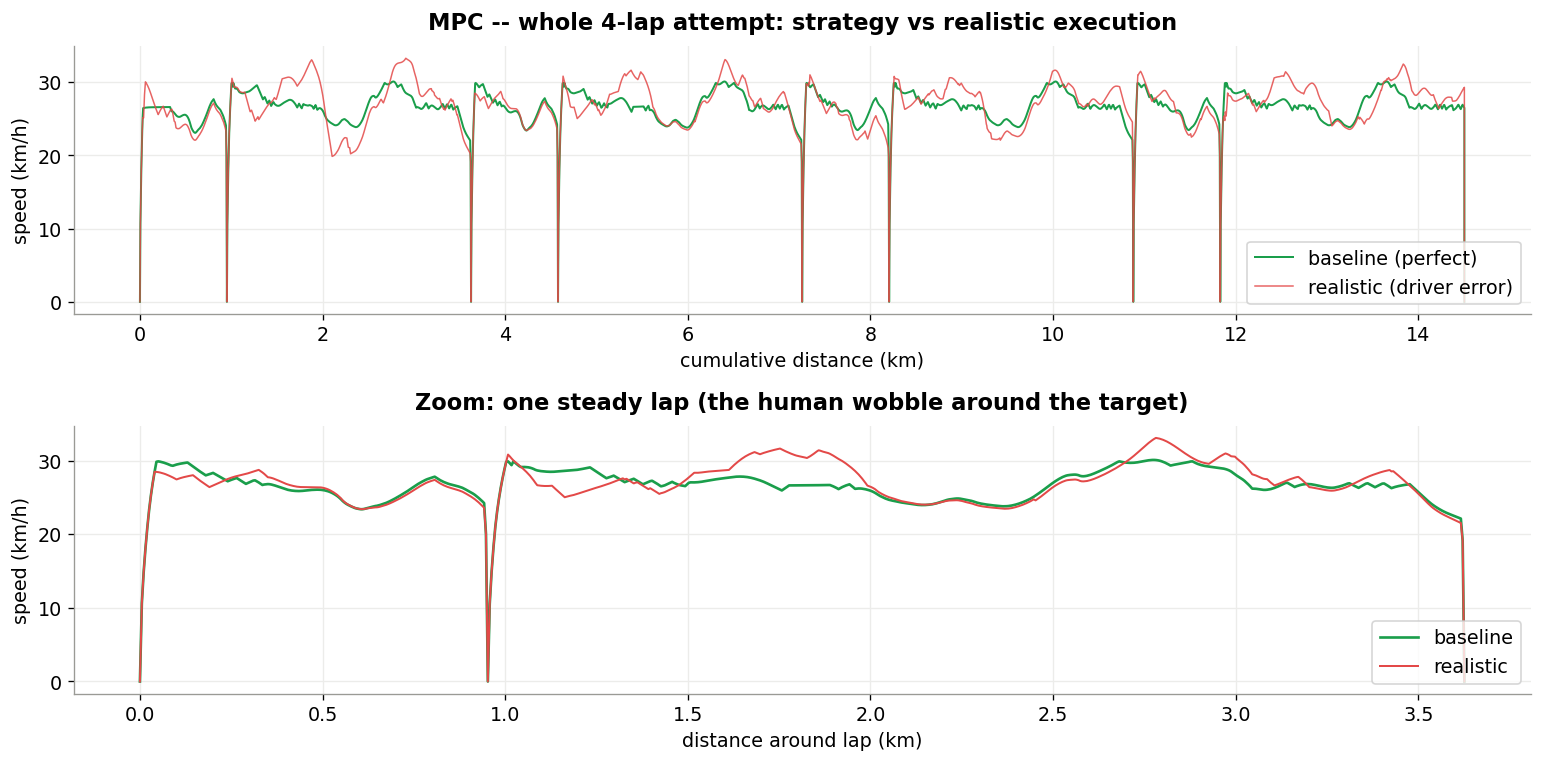

In [4]:
# ---- Speed profile: strategy (baseline) vs realistic driver (one steady lap + whole run) ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5))
ax1.plot(baseline['distance_km'], baseline['v_kmh'], color='#1a9e4b', lw=1.2, label='baseline (perfect)')
ax1.plot(realistic['distance_km'], realistic['v_kmh'], color='#e34948', lw=0.9, alpha=0.85, label='realistic (driver error)')
ax1.set_xlabel('cumulative distance (km)'); ax1.set_ylabel('speed (km/h)'); ax1.legend(loc='lower right')
ax1.set_title(MODEL.upper() + ' -- whole 4-lap attempt: strategy vs realistic execution')
lap2b = baseline[baseline['lap'] == 2]; lap2r = realistic[realistic['lap'] == 2]
ax2.plot(lap2b['lap_distance_km'], lap2b['v_kmh'], color='#1a9e4b', lw=1.6, label='baseline')
ax2.plot(lap2r['lap_distance_km'], lap2r['v_kmh'], color='#e34948', lw=1.2, label='realistic')
ax2.set_xlabel('distance around lap (km)'); ax2.set_ylabel('speed (km/h)'); ax2.legend(loc='lower right')
ax2.set_title('Zoom: one steady lap (the human wobble around the target)')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, '01_speed_profile.png')); plt.show()


## 4 - Hydrogen consumption

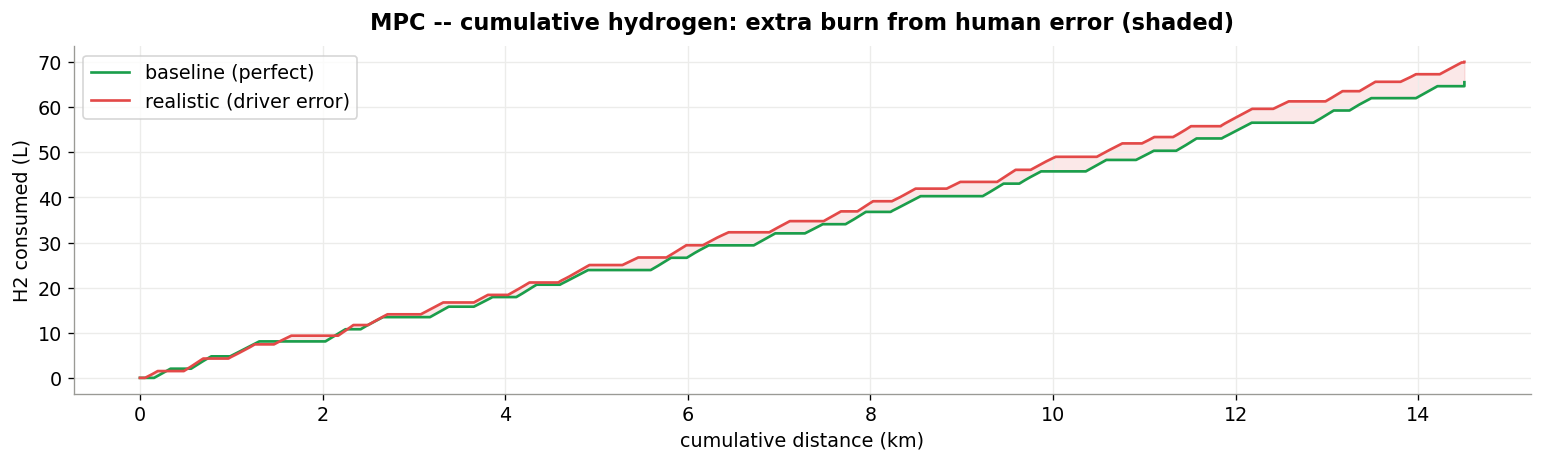

In [5]:
# ---- Hydrogen consumption: realistic driver burns slightly more ----
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(baseline['distance_km'], baseline['h2_cumulative_m3']*1000, color='#1a9e4b', lw=1.6, label='baseline (perfect)')
ax.plot(realistic['distance_km'], realistic['h2_cumulative_m3']*1000, color='#e34948', lw=1.6, label='realistic (driver error)')
ax.fill_between(realistic['distance_km'], baseline['h2_cumulative_m3']*1000, realistic['h2_cumulative_m3']*1000,
                color='#e34948', alpha=0.12)
ax.set_xlabel('cumulative distance (km)'); ax.set_ylabel('H2 consumed (L)')
ax.set_title(MODEL.upper() + ' -- cumulative hydrogen: extra burn from human error (shaded)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, '02_hydrogen.png')); plt.show()


## 5 - Driver-error statistics (distribution + fatigue per lap)

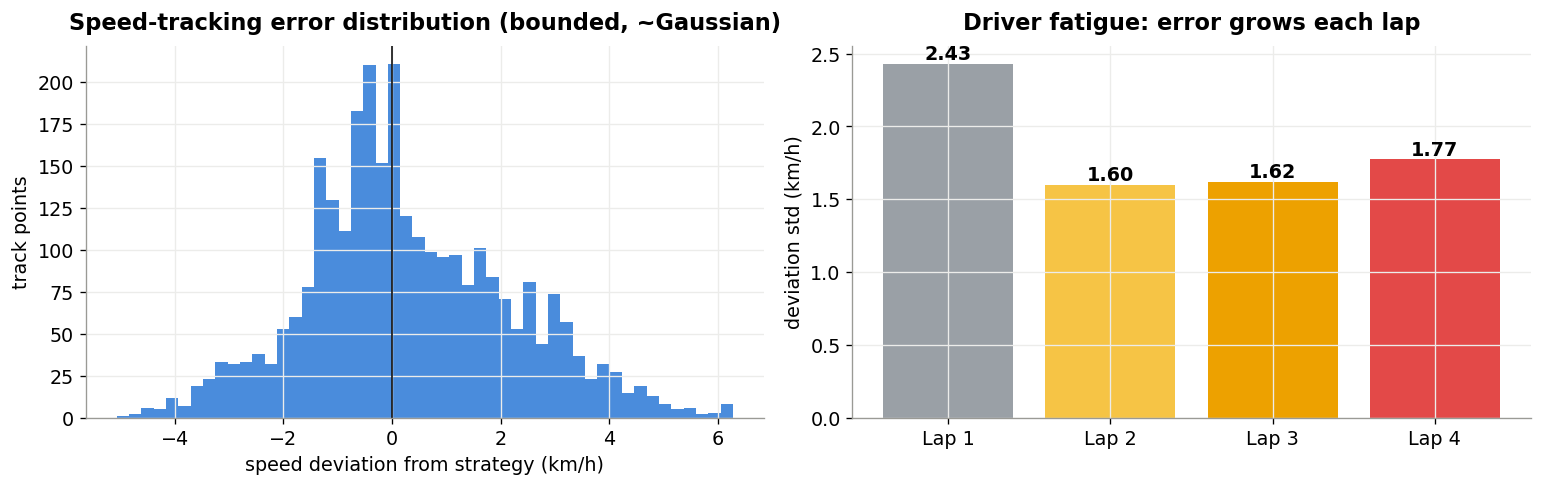

In [6]:
# ---- Driver-error statistics: deviation distribution + fatigue growth per lap ----
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4.2))
axa.hist(dev, bins=50, color='#2a78d6', alpha=0.85)
axa.axvline(0, color='#111', lw=1); axa.set_xlabel('speed deviation from strategy (km/h)')
axa.set_ylabel('track points'); axa.set_title('Speed-tracking error distribution (bounded, ~Gaussian)')
lap_std = [np.std(dev[realistic['lap'].to_numpy() == L]) for L in [1, 2, 3, 4]]
axb.bar(['Lap 1', 'Lap 2', 'Lap 3', 'Lap 4'], lap_std, color=['#9aa0a6', '#f6c445', '#eda100', '#e34948'])
for i, v in enumerate(lap_std): axb.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
axb.set_ylabel('deviation std (km/h)'); axb.set_title('Driver fatigue: error grows each lap')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, '03_driver_error_stats.png')); plt.show()


## 6 - Motor switching & servo-time sweep (0.5 / 1 / 2 / 3 s)
Changing the servo switch time automatically regenerates the telemetry.

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


,servo_s,score_km_per_m3,time_min,h2_litres,motor_switches,servo_overhead_s,legal
0,0.5,191.9,33.59,70.06,15,7.5,True
1,1.0,192.0,33.91,70.01,15,15.0,True
2,2.0,192.0,33.61,69.99,15,30.0,True
3,3.0,192.0,33.84,70.00,15,45.0,True


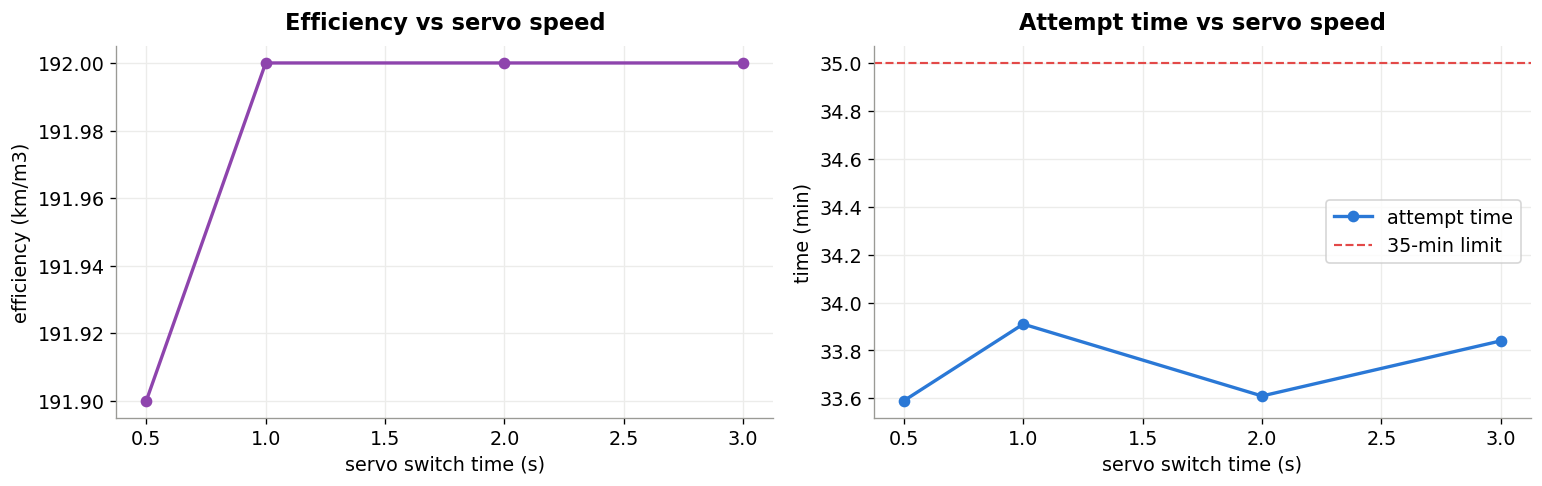

In [7]:
# ---- Motor-switching / servo sweep: 0.5 / 1 / 2 / 3 s per switch ----
rows = []
for sw in [0.5, 1.0, 2.0, 3.0]:
    t = ds.generate(MODEL, ds.DriverErrorConfig(enabled=True, seed=SEED, motor_switch_time_s=sw))
    s = ds.summary(t)
    rows.append({'servo_s': sw, 'score_km_per_m3': s['score_km_per_m3'], 'time_min': s['time_min'],
                 'h2_litres': s['h2_litres'], 'motor_switches': s['motor_handoffs'],
                 'servo_overhead_s': round(s['motor_handoffs']*sw, 1), 'legal': s['time_ok']})
servo_df = pd.DataFrame(rows); display(servo_df)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
axL.plot(servo_df.servo_s, servo_df.score_km_per_m3, 'o-', color='#8e44ad', lw=2)
axL.set_xlabel('servo switch time (s)'); axL.set_ylabel('efficiency (km/m3)'); axL.set_title('Efficiency vs servo speed')
axR.plot(servo_df.servo_s, servo_df.time_min, 'o-', color='#2a78d6', lw=2, label='attempt time')
axR.axhline(config.MAX_ATTEMPT_TIME_MIN, color='#e34948', ls='--', lw=1.3, label='35-min limit')
axR.set_xlabel('servo switch time (s)'); axR.set_ylabel('time (min)'); axR.set_title('Attempt time vs servo speed'); axR.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, '04_servo_sweep.png')); plt.show()


## 7 - Success-criteria check

In [8]:
# ---- Success-criteria check ----
n_stops_realistic = int((realistic['stop_event'] & (realistic['v_kmh'] < 0.5)).sum())
checks = {
    'Schema identical to baseline':        schema_ok,
    'Efficiency decreased (realistic)':    sr['score_km_per_m3'] < sb['score_km_per_m3'],
    'Hydrogen increased (realistic)':      sr['h2_litres'] > sb['h2_litres'],
    'Lap time < 35 min':                   sr['time_ok'],
    'No rule violations (safe)':           sr['rule_violations'] == 0,
    'Stop & Go still executed':            n_stops_realistic >= 1,
    'Telemetry not perfect (has wobble)':  np.abs(dev).max() > 0.5,
}
for k, v in checks.items():
    print(('  PASS' if v else '  FAIL') + '  ' + k)
_nfail = sum(1 for v in checks.values() if not v)
if _nfail == 0:
    print('\nAll success criteria PASSED.')
else:
    print(f'\n{_nfail} criterion did not pass (see FAIL above -- e.g. time margin under driver error + Art.56c recharge).')


  PASS  Schema identical to baseline
  PASS  Efficiency decreased (realistic)
  PASS  Hydrogen increased (realistic)
  PASS  Lap time < 35 min
  PASS  No rule violations (safe)
  PASS  Stop & Go still executed
  PASS  Telemetry not perfect (has wobble)

All success criteria PASSED.


## Hybrid fuel-cell + supercapacitor energy system  (SEM Art. 56c compliant)

The fuel cell runs in **parallel with a 3-series Maxwell BMOD0058 supercapacitor** feeding the
DC-DC converter. The FC is held at its **efficient operating point (558 W, 62%)** and the supercap
absorbs the launch peaks / returns energy during cruise; hydrogen is billed off the FC energy at
62% via Art. 54e's joulemeter formula. Per **SEM Art. 56c(iii)** the supercap voltage **after** the
run must be **>= before** it: the bank starts a little below full (headroom, so it can never
overcharge past V_max), and because the FC is idle most of the run it tops the cap back up to the
**start voltage** using that spare capacity -- so `V_end == V_start` at no extra run time. The lower
panel shows the supercap voltage returning exactly to its start line and never touching V_max.


MPC hybrid energy system (SEM Art. 56c compliant):
  Supercap 3S : 19.3 F, 48 V max, 66 mOhm, 6.19 Wh
  FC op point : 558 W @ 62% efficiency   |   FC duty cycle: 43%
  SEM 56c(iii): Vstart 45.54 V  ->  Vend 45.54 V   (Vend >= Vstart: True)
                peak 47.83 V < Vmax 48 V (no overcharge)   |   post-run recharge: 1.6 s
  H2 (FC 62%) : 70.06 L   ->   Art.54e score 191.9 km/m3


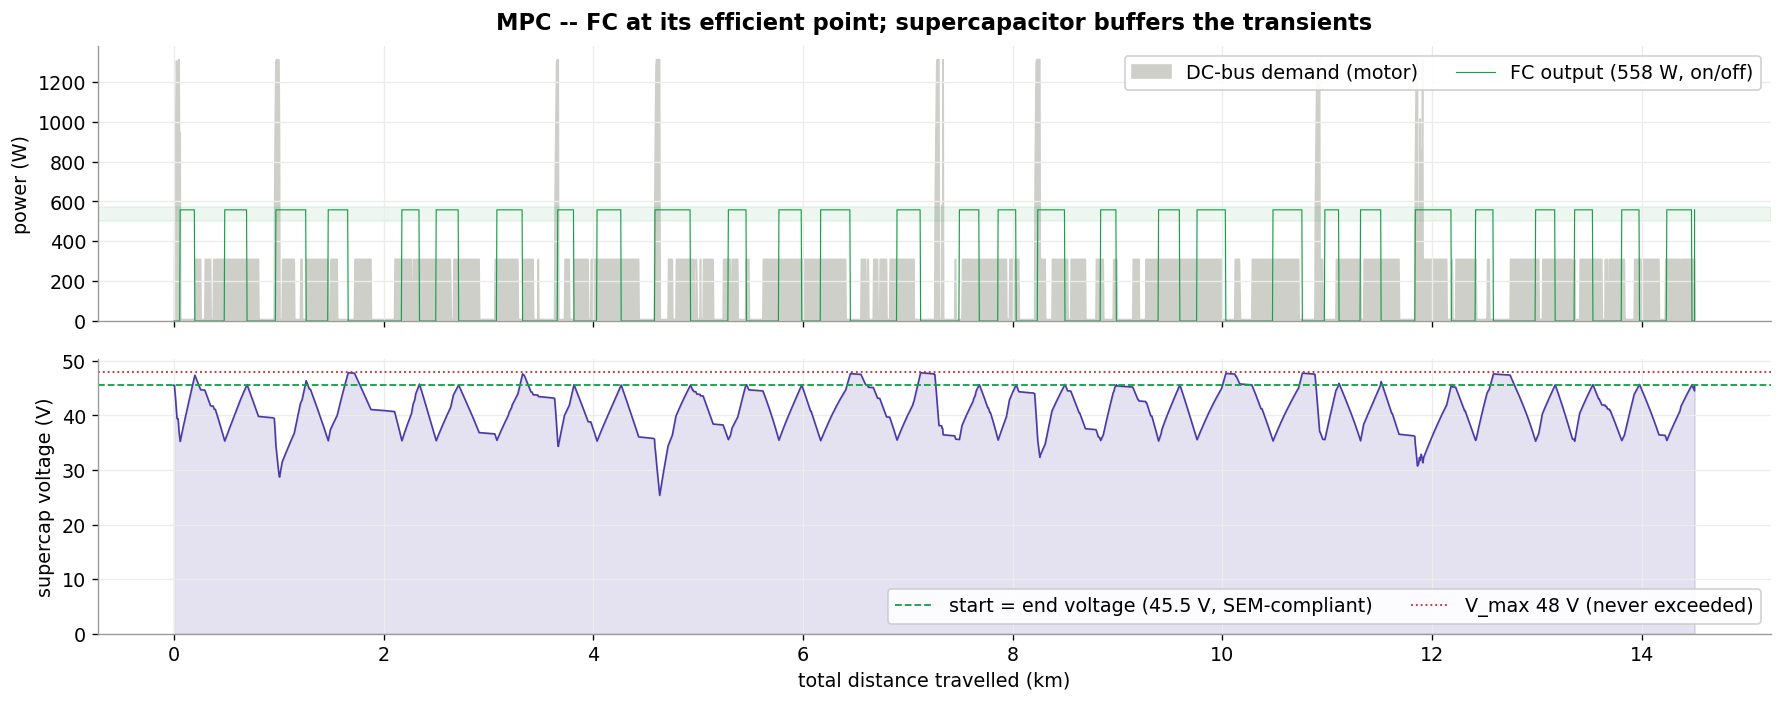

In [9]:
# ============ HYBRID FC + SUPERCAPACITOR ENERGY SYSTEM (SEM Art. 56c) =========
from digital_twin import hybrid_energy as _he
_D = realistic
_spec = _he.supercap_specs()
_duty = (_D.p_fc_out_w > 0).mean() * 100
_vmax = config.SUPERCAP_MODULE_V * config.SUPERCAP_N_SERIES
_vs, _ve = _D.supercap_v_start.iloc[0], _D.supercap_v_end.iloc[0]
print(f'{MODEL.upper()} hybrid energy system (SEM Art. 56c compliant):')
print(f'  Supercap 3S : {_spec["C"]:.1f} F, {_vmax:.0f} V max, {_spec["ESR"]*1000:.0f} mOhm, {_spec["E_max"]/3600:.2f} Wh')
print(f'  FC op point : {config.FC_HYBRID_OP_POWER_W:.0f} W @ {config.FC_HYBRID_EFF*100:.0f}% efficiency   |   FC duty cycle: {_duty:.0f}%')
print(f'  SEM 56c(iii): Vstart {_vs:.2f} V  ->  Vend {_ve:.2f} V   (Vend >= Vstart: {bool(_ve >= _vs - 1e-6)})')
print(f'                peak {_D.supercap_voltage_v.max():.2f} V < Vmax {_vmax:.0f} V (no overcharge)   |   post-run recharge: {_D.supercap_recharge_s.iloc[0]:.1f} s')
print(f'  H2 (FC 62%) : {sr["h2_litres"]} L   ->   Art.54e score {sr["score_km_per_m3"]} km/m3')

fig, (axA, axB) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axA.fill_between(_D.distance_km, 0, _D.p_fc_elec_w, color='#cfcfca', label='DC-bus demand (motor)')
axA.plot(_D.distance_km, _D.p_fc_out_w, color='#1a9e4b', lw=0.7, label=f'FC output ({config.FC_HYBRID_OP_POWER_W:.0f} W, on/off)')
axA.axhspan(config.FC_HYBRID_BAND_W[0], config.FC_HYBRID_BAND_W[1], color='#1a9e4b', alpha=0.08)
axA.set_ylabel('power (W)'); axA.set_ylim(0, None); axA.legend(loc='upper right', ncol=2, framealpha=0.9)
axA.set_title(f'{MODEL.upper()} -- FC at its efficient point; supercapacitor buffers the transients')
axB.fill_between(_D.distance_km, 0, _D.supercap_voltage_v, color='#4a3aa7', alpha=0.15)
axB.plot(_D.distance_km, _D.supercap_voltage_v, color='#4a3aa7', lw=1.0)
axB.axhline(_vs, color='#1a9e4b', ls='--', lw=1.1, label=f'start = end voltage ({_vs:.1f} V, SEM-compliant)')
axB.axhline(_vmax, color='#d62728', ls=':', lw=1.1, label=f'V_max {_vmax:.0f} V (never exceeded)')
axB.set_ylabel('supercap voltage (V)'); axB.set_xlabel('total distance travelled (km)')
axB.set_ylim(0, _vmax * 1.05); axB.legend(loc='lower right', framealpha=0.9, ncol=2)
plt.tight_layout(); plt.show()


## Summary

This notebook takes the **Model Predictive Control** strategy from the existing project and re-simulates it with a realistic human driver instead of a perfect one, via `margin/driver_sim.py`. The **strategy, track, vehicle, fuel cell and telemetry schema are unchanged** -- only the *execution* now carries the eight bounded driver errors (speed tracking, throttle, glide/accel/brake timing, corner entry, stop-and-go reaction, steering-line deviation), lap-by-lap fatigue, and the two-motor **servo switch cost** (0.5 s default, configurable to 1/2/3 s).

The realistic telemetry looks like a real run, not an optimizer: efficiency drops a few percent, hydrogen rises a few percent, the car wobbles around its target speed, motor switching costs a little energy -- yet the attempt stays **legal (<35 min), safe (0 violations) and completes both stop-and-gos every lap**, because the driver paces to the plan. The generated CSV (`margin/<MODEL>/<model>_driver_error_telemetry.csv`) is byte-for-byte schema-compatible with the existing analysis pipeline. Change `SERVO_S` (0.5/1/2/3 s) to regenerate the telemetry for a slower servo.